In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
from esem import rf_model
from eofs.xarray import Eof
import itertools
import joblib  
from sklearn.metrics import mean_squared_error
from utils import *
from utils_first_layer import *


2025-03-05 12:10:20.560004: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-05 12:10:20.568980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741201820.578232    4901 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741201820.581200    4901 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-05 12:10:20.592700: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
train_files= ['ssp126', 'ssp585', 'historical']

In [3]:
# get data
Xtrain, eof_solvers = create_predictor_data(train_files)

In [4]:
Ytrain = get_Ytrain(train_files)

In [5]:
Xtest = get_test_data('ssp370', eof_solvers)

In [6]:
Ytest = get_Ytest('ssp370')

### Start of RF Modeling

In [7]:
#parameters dictionary
param_dict = {
    'mai': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri1': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'ri2': {
        'n_estimators':550,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'soy': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'swh': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    },
    'wwh': {
        'n_estimators': 500,
        'min_samples_split': 5,
        'min_samples_leaf': 7,
        'max_depth': 5
    }
}


### Running RF model for years 2015-2100 each crop 

In [8]:
crop_variables = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh']

rf_models = {}
predictions_dict = {}
rmse_results = {}

for crop in crop_variables:
    print(f"Processing crop: {crop}")

    Ytrain_yield = Ytrain[crop].values.reshape(-1, 360*720)
    yield_truth = Ytest[crop]
    
    train_nan_mask = Xtrain.isna().any(axis=1).values
    Xtrain = Xtrain.dropna(axis=0, how='any')
    Ytrain_yield = Ytrain_yield[~train_nan_mask]
    assert Xtrain.shape[0]==Ytrain_yield.shape[0]

    
    test_nan_mask = Xtest.isna().any(axis=1).values
    Xtest = Xtest.dropna(axis=0, how='any')
    yield_truth = yield_truth[~test_nan_mask]

    mask_all_nan_by_col = np.isnan(Ytrain_yield).all(axis=0)
    Ytrain_yield_dropped = Ytrain_yield[:, ~mask_all_nan_by_col]
    Y_imputed = np.nan_to_num(Ytrain_yield_dropped, nan=0.0)
    
    
    rf = rf_model(
        Xtrain,
        Y_imputed,
        random_state=0,
        bootstrap=True,
        max_features='sqrt',
        **param_dict[crop]  
    )
    rf.train()
    rf_models[crop] = rf  # Store trained model

    # Predictions
    predictions = rf.predict(Xtest)
    predictions_array = predictions[0]  # Extract from tuple
    predictions_dict[crop] = predictions_array

Processing crop: mai


I0000 00:00:1741201830.084783    4901 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 42436 MB memory:  -> device: 0, name: NVIDIA L40, pci bus id: 0000:82:00.0, compute capability: 8.9


Processing crop: ri1
Processing crop: ri2
Processing crop: soy
Processing crop: swh
Processing crop: wwh


In [34]:
predictions_full = {}
for crop, pred in predictions_dict.items():
    pred_full = np.full((Xtest.shape[0], Ytrain_yield.shape[1]), np.nan)  # fill with NaN
    mask_all_nan_by_col = np.isnan(Ytrain[crop]).all(axis=0).values.reshape(360*720)
    pred_full[:, ~mask_all_nan_by_col] = pred
    predictions_full[crop] = pred_full

In [65]:
predictions_ds = {}
for crop, pred in predictions_full.items():
    pred = pred.reshape(-1, 360, 720)
    ds = xr.DataArray(pred, dims=yield_truth.dims, coords=yield_truth.coords)
    predictions_ds[crop] = ds

In [74]:
# RMSE for all years per crop 
def get_rmse(truth, pred):
    weights = np.cos(np.deg2rad(truth.lat))
    return np.sqrt(((truth - pred)**2).weighted(weights).mean(['lat', 'lon'])).data
rmses = {}
for crop, pred in predictions_ds.items():
    rmse = get_rmse(Ytest[crop], predictions_ds[crop])
    rmses[crop] = rmse

In [88]:
for crop, pred in predictions_ds.items():
    yield_truth = Ytest[crop]
    print(crop)
    # Compute RMSEs
    print(f"RMSE at 2050: {get_rmse(yield_truth[35], pred[35])}")
    print(f"RMSE at 2100: {get_rmse(yield_truth[85], pred[85])}")
    print(f"RMSE 2045-2055: {get_rmse(yield_truth[30:41], pred[30:41]).mean()}")
    print(f"RMSE 2090-2100: {get_rmse(yield_truth[75:], pred[75:]).mean()}")
    print(f"RMSE 2050-2100: {get_rmse(yield_truth[35:], pred[35:]).mean()}")
    
    # RMSE for average field over last 20 years
    print(f"RMSE average last 20y: {get_rmse(yield_truth[-20:].mean(dim='time'), pred[-20:].mean(dim='time'))}")

mai
RMSE at 2050: 0.6044529727488412
RMSE at 2100: 0.7651192512275339
RMSE 2045-2055: 0.5722622998598231
RMSE 2090-2100: 0.6650084253160736
RMSE 2050-2100: 0.6266115285323416
RMSE average last 20y: 0.4060079221920802
ri1
RMSE at 2050: 0.5879586817933463
RMSE at 2100: 0.9027596646340086
RMSE 2045-2055: 0.5686850209416918
RMSE 2090-2100: 0.8289879591106992
RMSE 2050-2100: 0.7053481039761302
RMSE average last 20y: 0.6038474364534365
ri2
RMSE at 2050: 0.4641301308194524
RMSE at 2100: 0.7004724725045608
RMSE 2045-2055: 0.433005326297241
RMSE 2090-2100: 0.6685079130268498
RMSE 2050-2100: 0.5479806822654423
RMSE average last 20y: 0.4790180149673801
soy
RMSE at 2050: 0.9243656237553498
RMSE at 2100: 1.393433966412456
RMSE 2045-2055: 0.9153576802166498
RMSE 2090-2100: 1.2186884382943923
RMSE 2050-2100: 1.0921254334724573
RMSE average last 20y: 0.7765321105970382
swh
RMSE at 2050: 0.6424506226934522
RMSE at 2100: 1.2315928302666441
RMSE 2045-2055: 0.6814642474653989
RMSE 2090-2100: 1.05876140205

In [78]:
import plotly.graph_objects as go
import numpy as np
import matplotlib.colors as cm

labels = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh']
colors = [cm.to_hex(plt.cm.tab10(i)) for i in range(6)]

mode_size = [8, 8, 8, 8, 8, 8]
line_size = [4, 4, 4, 4, 4, 4]

x_data = np.vstack((np.arange(2015, 2100),)*6)

y_data = np.array([rmse for rmse in rmses.values()])

fig = go.Figure()

for i in range(0, 6):
    fig.add_trace(go.Scatter(x=x_data[i], y=y_data[i], mode='lines',
        name=labels[i],
        line=dict(color=colors[i], width=line_size[i]),
    ))



fig.update_layout(
    xaxis=dict(
        showline=True,
        showgrid=True,
        showticklabels=True,
        linecolor='rgb(0, 0, 0)',
        linewidth=4,
        ticks='outside',
        tickfont=dict(
            family='Arial',
            size=36,
            color='rgb(82, 82, 82)',
        ),
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='rgb(230, 230, 230)',
        showline=True,
        showticklabels=True,
        linecolor='rgb(0, 0, 0)',
        linewidth=4,
        ticks='outside',
        tickfont=dict(
            family='Arial',
            size=36,
            color='rgb(82, 82, 82)',
        ),
    ),
    autosize=False,
    margin=dict(
        autoexpand=False,
        l=100,
        r=20,
        t=110,
    ),
    showlegend=True,
)

annotations = []


# Title
annotations.append(dict(xref='paper', yref='paper', x=0.4, y=0.98,
                              xanchor='left', yanchor='bottom',
                              text='RF - RMSE over time',
                              font=dict(family='Arial',
                                        size=36,
                                        color='rgb(37,37,37)'),
                              showarrow=False))

legend = dict(
        font=dict(size=30, color="black"),
        bgcolor="rgba(0, 0, 0, 0)",
        orientation="h",
        x=0.2,
        xanchor="center",
        y=0.95,
        yanchor="top",
    )
fig.update_layout(annotations=annotations,
                  legend=legend,
                  paper_bgcolor='rgba(0,0,0,0)',  # Transparent background
                  plot_bgcolor='rgba(0,0,0,0)',    # Transparent plot area
                  # Ensure good dpi
                  width=1800,
                  height=1200,
)
fig.show()

In [90]:
predictions_full.keys()

dict_keys(['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh'])

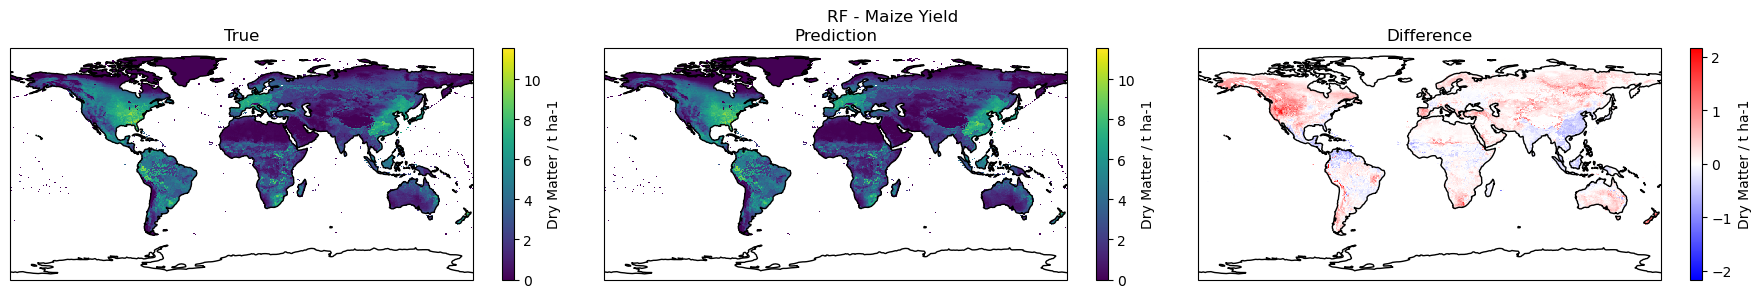

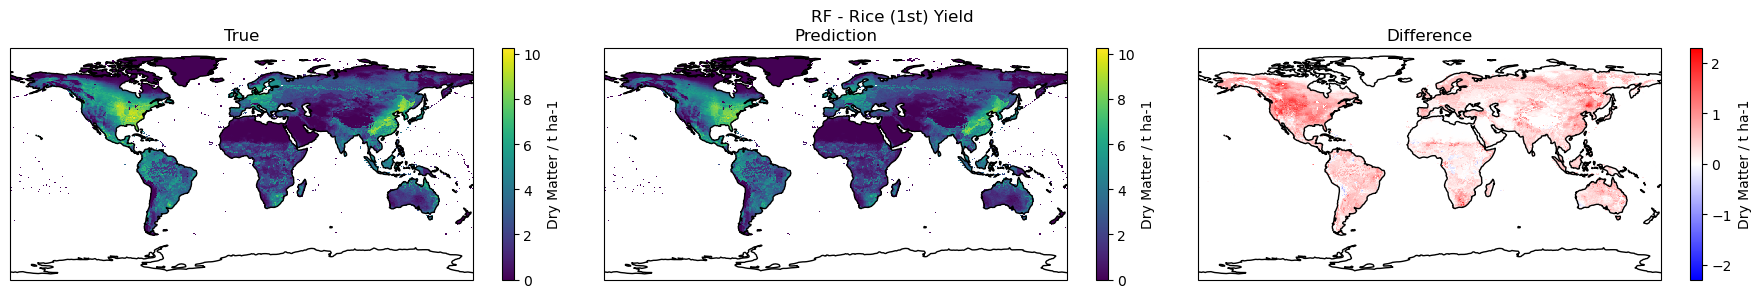

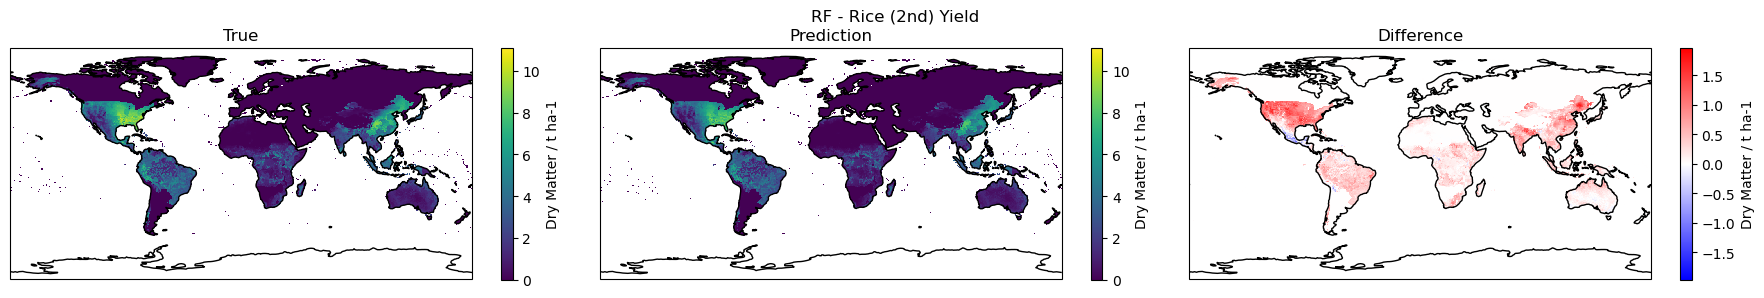

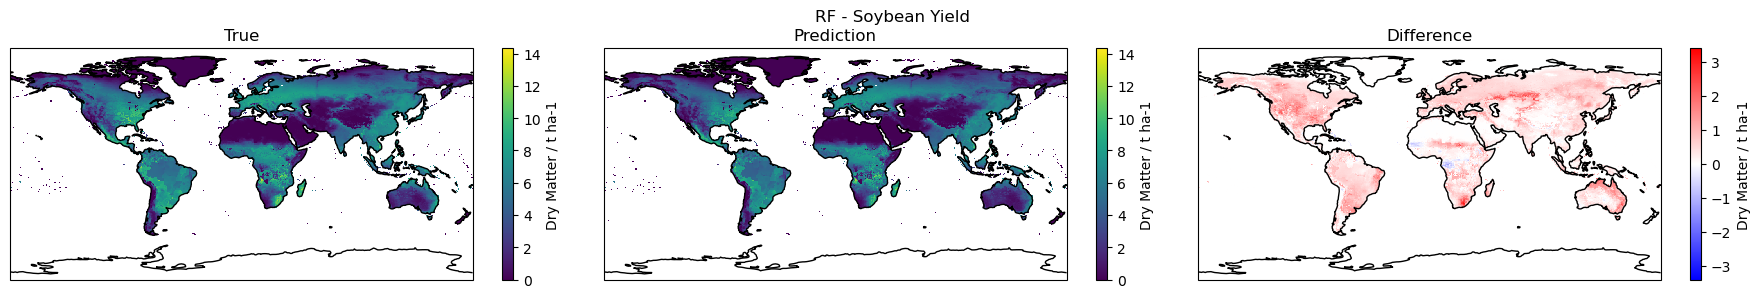

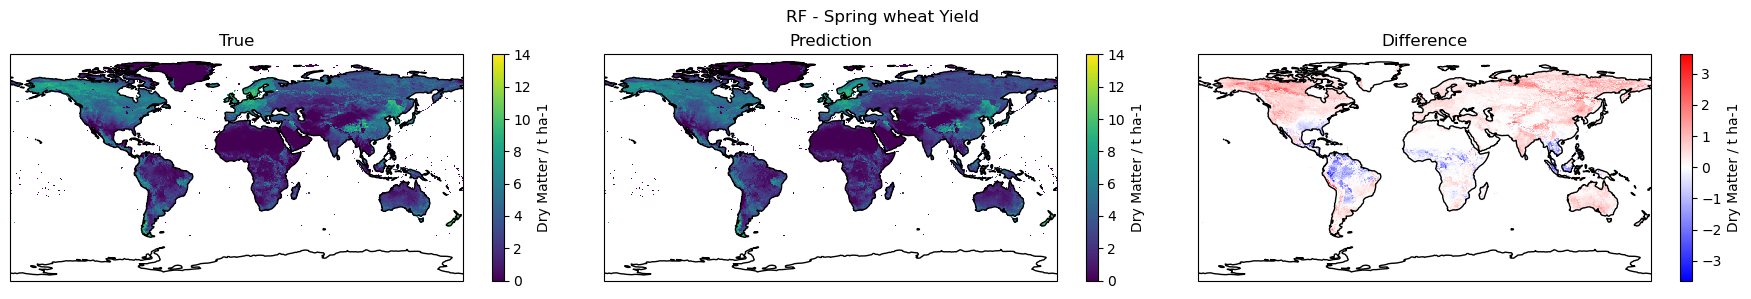

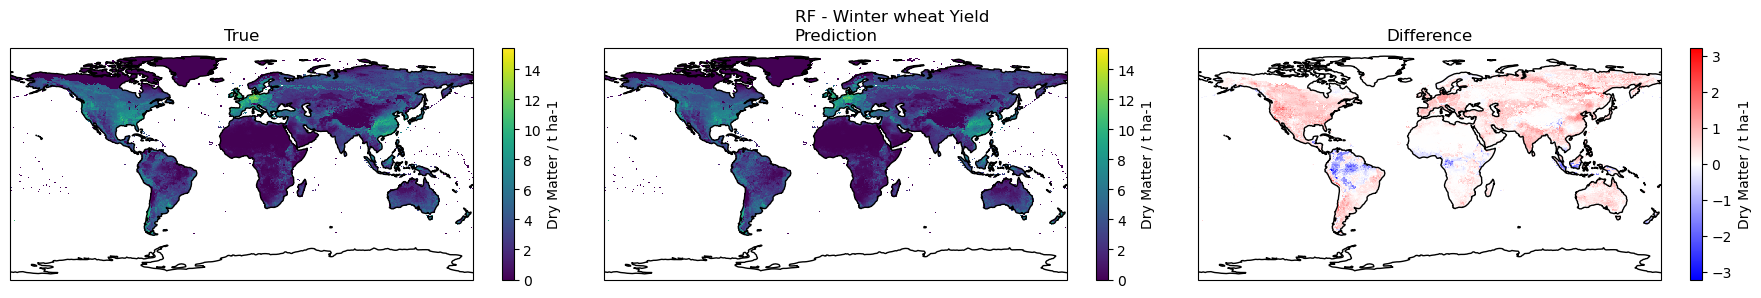

In [98]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib import colors

crop_name = {
    'mai': 'Maize',
    'ri1': 'Rice (1st)',
    'ri2': 'Rice (2nd)',
    'soy': 'Soybean',
    'swh': 'Spring wheat',
    'wwh': 'Winter wheat'
}

for crop, pred in predictions_ds.items():
    yield_truth = Ytest[crop]
    
    truth_mean = yield_truth.sel(time=slice(2050,None)).mean('time')
    posterior_mean = pred.sel(time=slice(2050,None)).mean('time')
    difference = truth_mean - posterior_mean
    
    tmin, tmax = float(truth_mean.min()), float(truth_mean.max())
    pmin, pmax = float(posterior_mean.min()), float(posterior_mean.max())
    dmin, dmax = float(difference.min()), float(difference.max())
    
    
    buffer = 0.001
    vmin = tmin - buffer
    vmax = tmax + buffer
    
    
    abs_max_diff = max(abs(dmin), abs(dmax))
    diffnorm = colors.TwoSlopeNorm(vcenter=0., vmin=-abs_max_diff, vmax=abs_max_diff)
    
    # Plot
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(18,3))
    fig.suptitle(f'RF - {crop_name[crop]} Yield')
    
    # 1) Truth
    ax1 = plt.subplot(131, projection=proj)
    truth_mean.plot(
        ax=ax1, cmap="viridis",
        vmin=vmin, vmax=vmax,
        cbar_kwargs={"label":"Dry Matter / t ha-1"}
    )
    ax1.coastlines()
    ax1.set_title('True')
    
    # 2) Posterior
    ax2 = plt.subplot(132, projection=proj)
    posterior_mean.plot(
        ax=ax2, cmap="viridis",
        vmin=vmin, vmax=vmax,
        cbar_kwargs={"label":"Dry Matter / t ha-1"}
    )
    ax2.coastlines()
    ax2.set_title('Prediction')
    
    # 3) Difference
    ax3 = plt.subplot(133, projection=proj)
    difference.plot(
        ax=ax3, cmap="bwr",
        norm=diffnorm,
        cbar_kwargs={"label":"Dry Matter / t ha-1"}
    )
    ax3.coastlines()
    ax3.set_title('Difference')
    
    plt.tight_layout()
    plt.show()
    fig.savefig(f'./figs/RF-{crop}.png', transparent=True, dpi=300, format='png')
